In [32]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings


warnings.filterwarnings('ignore')

In [33]:
data = pd.read_csv("../data/indian_tech_jobs_2026.csv")


In [34]:
data.shape

(23201, 32)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  object 
 2   company_name         23201 non-null  object 
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  object 
 5   scraped_city         23201 non-null  object 
 6   role_category        23201 non-null  object 
 7   experience_raw       23201 non-null  object 
 8   experience_min_yrs   23201 non-null  float64
 9   experience_max_yrs   23201 non-null  float64
 10  salary_raw           23201 non-null  object 
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  object 
 15  skills_count         23201 non-null 

In [36]:
data.describe()

,job_id,company_rating,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,skills_count,salary_midpoint_lpa,days_since_posted
count,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000
mean,11601.000000,3.586449,4.135080,7.829059,1.383952,2.271790,7.604198,1.827872,15.698935
std,6697.696134,0.514250,2.933976,3.946834,4.841570,7.469383,1.456530,6.109373,7.575881
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5801.000000,3.400000,2.000000,5.000000,0.000000,0.000000,8.000000,0.000000,7.000000
50%,11601.000000,3.600000,4.000000,8.000000,0.000000,0.000000,8.000000,0.000000,21.000000
75%,17401.000000,3.800000,6.000000,10.000000,0.000000,0.000000,8.000000,0.000000,21.000000
max,23201.000000,5.000000,25.000000,31.000000,85.000000,90.000000,8.000000,87.500000,90.000000


In [37]:
data.head(5)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [38]:
data.columns

Index(['job_id', 'job_title', 'company_name', 'company_rating', 'location',
       'scraped_city', 'role_category', 'experience_raw', 'experience_min_yrs',
       'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa',
       'salary_disclosed', 'skills_required', 'skills_count',
       'job_description', 'posted_date_raw', 'work_mode',
       'company_size_bucket', 'job_url', 'data_source', 'scraped_at',
       'salary_tier', 'experience_tier', 'is_senior', 'primary_city',
       'skill_domain', 'salary_midpoint_lpa', 'days_since_posted',
       'is_fresher_friendly', 'salary_negotiable'],
      dtype='object')

In [39]:
data.dtypes

job_id                   int64
job_title               object
company_name            object
company_rating         float64
location                object
scraped_city            object
role_category           object
experience_raw          object
experience_min_yrs     float64
experience_max_yrs     float64
salary_raw              object
salary_min_lpa         float64
salary_max_lpa         float64
salary_disclosed          bool
skills_required         object
skills_count             int64
job_description         object
posted_date_raw         object
work_mode               object
company_size_bucket     object
job_url                 object
data_source             object
scraped_at              object
salary_tier             object
experience_tier         object
is_senior                 bool
primary_city            object
skill_domain            object
salary_midpoint_lpa    float64
days_since_posted      float64
is_fresher_friendly       bool
salary_negotiable         bool
dtype: o

In [40]:
data.isna().sum()

job_id                  0
job_title               0
company_name            0
company_rating          0
location                0
scraped_city            0
role_category           0
experience_raw          0
experience_min_yrs      0
experience_max_yrs      0
salary_raw              0
salary_min_lpa          0
salary_max_lpa          0
salary_disclosed        0
skills_required         0
skills_count            0
job_description         0
posted_date_raw         0
work_mode               0
company_size_bucket     0
job_url                53
data_source             0
scraped_at              0
salary_tier             0
experience_tier         0
is_senior               0
primary_city            0
skill_domain            0
salary_midpoint_lpa     0
days_since_posted       0
is_fresher_friendly     0
salary_negotiable       0
dtype: int64

In [41]:
data = data.drop("job_url",axis=1)
data

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23196,23197,Python Developer-Hyderabad,Infosys,3.5,Hybrid - Hyderabad,Hyderabad,Python Developer,2-7 Yrs,2.0,7.0,...,2025-06-10,Undisclosed,Junior (0-2 Yrs),False,Hyderabad,Data Science,0.0,1.0,False,False
23197,23198,Python Developer,Accufy,3.6,Hyderabad,Hyderabad,Python Developer,0-4 Yrs,0.0,4.0,...,2025-06-10,Undisclosed,Fresher,False,Hyderabad,Data Science,0.0,1.0,True,False
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,3.3,"Hyderabad, Pune, Mumbai (All Areas)",Hyderabad,Python Developer,13 Jun,13.0,8.0,...,2025-06-10,Undisclosed,Lead/Architect (9+ Yrs),False,Hyderabad,Data Engineering,0.0,21.0,False,False
23199,23200,Python Developer,Mediamint,2.8,Hybrid - Hyderabad,Hyderabad,Python Developer,3-5 Yrs,3.0,5.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,0.0,False,False


In [42]:
data.duplicated().sum()

np.int64(0)

In [43]:
data.dtypes

job_id                   int64
job_title               object
company_name            object
company_rating         float64
location                object
scraped_city            object
role_category           object
experience_raw          object
experience_min_yrs     float64
experience_max_yrs     float64
salary_raw              object
salary_min_lpa         float64
salary_max_lpa         float64
salary_disclosed          bool
skills_required         object
skills_count             int64
job_description         object
posted_date_raw         object
work_mode               object
company_size_bucket     object
data_source             object
scraped_at              object
salary_tier             object
experience_tier         object
is_senior                 bool
primary_city            object
skill_domain            object
salary_midpoint_lpa    float64
days_since_posted      float64
is_fresher_friendly       bool
salary_negotiable         bool
dtype: object

In [44]:

# Convert date columns to datetime
data['posted_date_raw'] = pd.to_datetime(data['posted_date_raw'], errors='coerce')
data['scraped_at'] = pd.to_datetime(data['scraped_at'], errors='coerce')

# Verify updated data types
print(data.dtypes)

job_id                          int64
job_title                      object
company_name                   object
company_rating                float64
location                       object
scraped_city                   object
role_category                  object
experience_raw                 object
experience_min_yrs            float64
experience_max_yrs            float64
salary_raw                     object
salary_min_lpa                float64
salary_max_lpa                float64
salary_disclosed                 bool
skills_required                object
skills_count                    int64
job_description                object
posted_date_raw        datetime64[ns]
work_mode                      object
company_size_bucket            object
data_source                    object
scraped_at             datetime64[ns]
salary_tier                    object
experience_tier                object
is_senior                        bool
primary_city                   object
skill_domain

In [45]:
# Remove leading and trailing spaces from text columns
text_columns = data.select_dtypes(include='object').columns

for col in text_columns:
    data[col] = data[col].str.strip()

# Standardize text to title case
data['location'] = data['location'].str.title()
data['scraped_city'] = data['scraped_city'].str.title()
data['primary_city'] = data['primary_city'].str.title()
data['company_name'] = data['company_name'].str.title()
data['work_mode'] = data['work_mode'].str.title()
data['role_category'] = data['role_category'].str.title()

# Verify the changes
data.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign It Consulting Mnc,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 It Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-Based Mnc,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


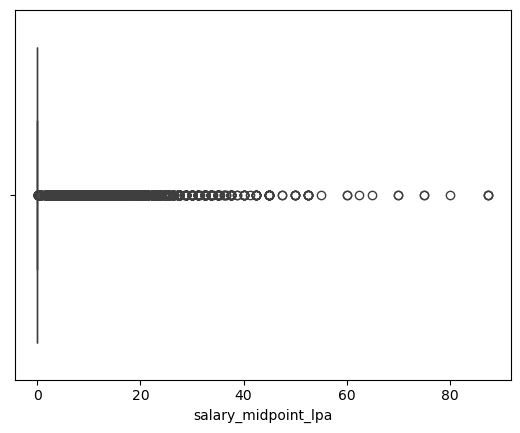

In [46]:
sns.boxplot(x=data['salary_midpoint_lpa'])
plt.show()

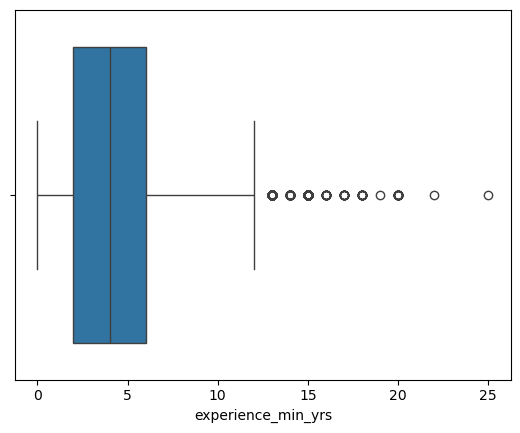

In [47]:
sns.boxplot(x=data['experience_min_yrs'])
plt.show()

In [48]:
# Select numerical columns
numerical_columns = [
    'company_rating',
    'experience_min_yrs',
    'experience_max_yrs',
    'salary_min_lpa',
    'salary_max_lpa',
    'salary_midpoint_lpa',
    'skills_count',
    'days_since_posted'
]

# Display summary statistics
data[numerical_columns].describe()

,company_rating,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,salary_midpoint_lpa,skills_count,days_since_posted
count,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000
mean,3.586449,4.135080,7.829059,1.383952,2.271790,1.827872,7.604198,15.698935
std,0.514250,2.933976,3.946834,4.841570,7.469383,6.109373,1.456530,7.575881
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.400000,2.000000,5.000000,0.000000,0.000000,0.000000,8.000000,7.000000
50%,3.600000,4.000000,8.000000,0.000000,0.000000,0.000000,8.000000,21.000000
75%,3.800000,6.000000,10.000000,0.000000,0.000000,0.000000,8.000000,21.000000
max,5.000000,25.000000,31.000000,85.000000,90.000000,87.500000,8.000000,90.000000


In [49]:
for col in numerical_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

company_rating: 2685 outliers
experience_min_yrs: 414 outliers
experience_max_yrs: 533 outliers
salary_min_lpa: 2705 outliers
salary_max_lpa: 2766 outliers
salary_midpoint_lpa: 2766 outliers
skills_count: 2356 outliers
days_since_posted: 4 outliers


In [50]:
################# Feature Selection ("Keeping only IMP columns ")
# Select relevant features for analysis
selected_features = [
    'job_title',
    'company_name',
    'company_rating',
    'location',
    'role_category',
    'experience_min_yrs',
    'experience_max_yrs',
    'salary_min_lpa',
    'salary_max_lpa',
    'salary_midpoint_lpa',
    'salary_disclosed',
    'skills_required',
    'skills_count',
    'work_mode',
    'company_size_bucket',
    'salary_tier',
    'experience_tier',
    'is_senior',
    'primary_city',
    'skill_domain',
    'days_since_posted',
    'is_fresher_friendly',
    'salary_negotiable'
]

data_selected = data[selected_features]

# Display selected dataset
data_selected.head()





,job_title,company_name,company_rating,location,role_category,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,salary_midpoint_lpa,...,work_mode,company_size_bucket,salary_tier,experience_tier,is_senior,primary_city,skill_domain,days_since_posted,is_fresher_friendly,salary_negotiable
0,Data Scientist,Cisco,4.1,Bengaluru,Data Scientist,7.0,10.0,0.0,0.0,0.0,...,On-Site,Large (1000+),Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,21.0,False,False
1,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Data Scientist,4.0,8.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,21.0,False,False
2,Analytics Data Scientist,Foreign It Consulting Mnc,3.6,"Hyderabad, Chennai, Bengaluru",Data Scientist,4.0,9.0,0.0,0.0,0.0,...,On-Site,Large (1000+),Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,21.0,False,False
3,Data Scientist,Fortune 500 It Services Company,3.6,"Mumbai, Bengaluru",Data Scientist,0.0,0.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Fresher,False,Mumbai,Data Science,21.0,True,False
4,Sr. Artificial Intelligence Engineer,Fortune 500 Product-Based Mnc,3.6,"Pune, Bengaluru",Data Scientist,5.0,10.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,21.0,False,False


In [51]:
# Convert categorical columns to category datatype
categorical_columns = [
    'job_title',
    'company_name',
    'location',
    'role_category',
    'work_mode',
    'company_size_bucket',
    'salary_tier',
    'experience_tier',
    'primary_city',
    'skill_domain'
]

for col in categorical_columns:
    data_selected[col] = data_selected[col].astype('category')

# Check updated data types
data_selected.dtypes

job_title              category
company_name           category
company_rating          float64
location               category
role_category          category
experience_min_yrs      float64
experience_max_yrs      float64
salary_min_lpa          float64
salary_max_lpa          float64
salary_midpoint_lpa     float64
salary_disclosed           bool
skills_required          object
skills_count              int64
work_mode              category
company_size_bucket    category
salary_tier            category
experience_tier        category
is_senior                  bool
primary_city           category
skill_domain           category
days_since_posted       float64
is_fresher_friendly        bool
salary_negotiable          bool
dtype: object